In [1]:
import matplotlib.pyplot as plt
import numpy as np

from MCTDHF_direct_jax import *

import jax.numpy as jnp
from jax import jit

from integrators import *

import sys
sys.path.insert(0, '..')
from electron_integrals import *
sys.path.remove('..')

Define number of electrons and orbitals

In [2]:
# Number of spatial orbitals
num_spatial_orbitals = 21
# Number of electrons
num_alpha_electrons = 1
num_beta_electrons = 1
# Number of MCTDHF orbitals
num_mctdhf_orbitals = 4
num_states=4

Calculate electron integrals

In [21]:
# Finite-Difference (same parameters as in Zhangellini)
x = np.linspace(-10, 10, 201)
pot = HOPotential(0.25)
spf, h = get_spf_and_diag_h(num_spatial_orbitals, x, pot)

# num_grid_points = len(x)
# # Assume even spacing
# dx = abs(x[1] - x[0])
# h_diag = 1.0 / (dx**2) + pot(x[1:-1])
# h_off_diag = -1.0 / (2 * dx**2) * np.ones(num_grid_points - 3)
# H = np.diag(h_diag) + np.diag(h_off_diag, 1) + np.diag(h_off_diag, -1)
# H = np.pad(H, 1)

# print(np.diag((spf@H@spf.T)*dx))
# print(np.diag(h))

## This makes the matrix singular...
# non_ort = (spf[0,:]+spf[1,:])/np.sqrt(2)
# spf = np.insert(spf, 1, non_ort, axis=0)

# print(non_ort@H@non_ort*dx)
# print(non_ort@H@spf[0,:]*dx)
# print(non_ort@H@spf[2,:]*dx)

# spf[1,:] = (spf[1,:]+spf[0,:])/np.sqrt(2)

# # h = np.insert(h, 1, np.zeros(spf.shape[0]-1), axis=0)
# # h = np.insert(h, 1, np.zeros(spf.shape[0]), axis=1)

# h[0,1] = h[0,0]/np.sqrt(2)
# h[1,0] = h[0,0]/np.sqrt(2)
# h[1,1] = (h[0,0]+h[1,1])/2
#print(h)

In [22]:
g = coulomb_interaction_matrix_elements(spf, spf, x, x, kappa = 1, a = 0.25)

In [24]:
S = spf@spf.T
print(S)

[[ 1.00000000e+01  2.09503744e-14 -3.88966237e-15 -2.41520571e-14
  -3.42341241e-15 -1.41205187e-14  5.29431184e-15 -1.25387735e-14
   1.75970072e-15 -6.71390170e-15 -8.25687365e-16  4.47991479e-15
   1.37518276e-15  4.42772069e-15 -4.36391265e-15  4.54805898e-15
   2.56002857e-15 -2.08233402e-15 -2.70576009e-15 -3.80928880e-15
   3.09546068e-15]
 [ 2.09503744e-14  1.00000000e+01  1.98019046e-13  2.88344892e-14
  -8.25618034e-15 -1.61166000e-15 -2.60299621e-15 -8.78145935e-15
  -2.26341591e-15 -6.06866228e-15 -5.83526002e-16  3.00619765e-15
   3.47023191e-15  6.51307863e-16 -1.84849604e-15 -1.18373134e-15
   1.86252486e-17  2.01595125e-15 -1.32537773e-15  4.99174813e-16
  -7.72544536e-16]
 [-3.88966237e-15  1.98019046e-13  1.00000000e+01  1.18667227e-13
   5.48183483e-14  3.71729332e-14 -2.94687623e-14  4.84477612e-16
   1.48164849e-14 -1.67815089e-14 -6.17082002e-15  1.62410734e-14
  -1.14636347e-15  6.84651688e-15  7.74231232e-15 -1.07377416e-16
  -5.72360252e-15  8.10842922e-15  2.4

In [6]:
def get_MCTDHF(h, ht, g, num_mctdhf_orbitals, num_spatial_orbitals, 
                 num_alpha_electrons, num_beta_electrons, num_states=1, imag_time=False, S=None):

    return MCTDHF(h, ht, g, num_mctdhf_orbitals, num_spatial_orbitals, 
                  num_alpha_electrons, num_beta_electrons, num_states, imag_time, S)

Imaginary time propagation

In [27]:
mctdhf = get_MCTDHF(h, lambda t: 0, g, num_mctdhf_orbitals, 
                num_spatial_orbitals, num_alpha_electrons, 
                num_beta_electrons, num_states, imag_time=True)#, S=S)

#integrator = get_dormand_prince_solver(mctdhf, 1e-2)
integrator = get_runge_kutta_4_solver(mctdhf, 1e-3)
ts, Es, Cs, bs = mctdhf.integrate(integrator, num_steps = 5000)

Plot

In [14]:
## Test that the states are orthogonal

for i,C in enumerate(Cs[-1]):
    t = np.zeros(num_states, dtype=np.complex64)
    t[i] = 1
    t2 = mctdhf.calculate_overlap(bs[-1],Cs[-1],bs[-1],np.array([C]*num_states))
    print(t2)
    np.testing.assert_allclose(t,t2, atol=1e-4)


[ 9.9998468e-01+0.j  2.3690518e-06+0.j -4.4074841e-07+0.j
 -1.6018748e-06+0.j]
[ 2.364628e-06+0.j  9.999809e-01+0.j  2.647459e-06+0.j -6.221235e-07+0.j]
[-4.3248292e-07+0.j  2.6614725e-06+0.j  9.9998569e-01+0.j
 -6.2724575e-07+0.j]
[-1.6056001e-06+0.j -6.2584877e-07+0.j -6.3027255e-07+0.j
  9.9998522e-01+0.j]


Final energy: [0.86392117+0.j 0.8524308 +0.j 1.1872108 +0.j 1.5045004 +0.j]


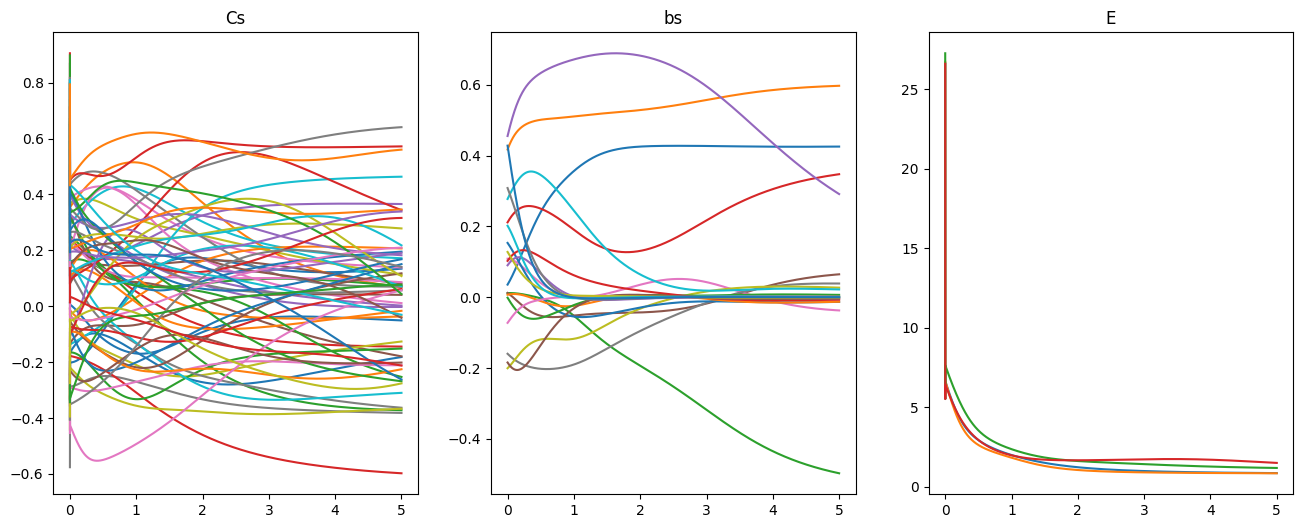

In [28]:
print(f"Final energy: {Es[-1]}")
#print(f"Max overlap coeff (ideally zero): {np.abs(np.max(b_f.T@b_f-np.eye(num_mctdhf_orbitals)))}")

mctdhf.plot_Cbe(ts, Cs, bs, Es)

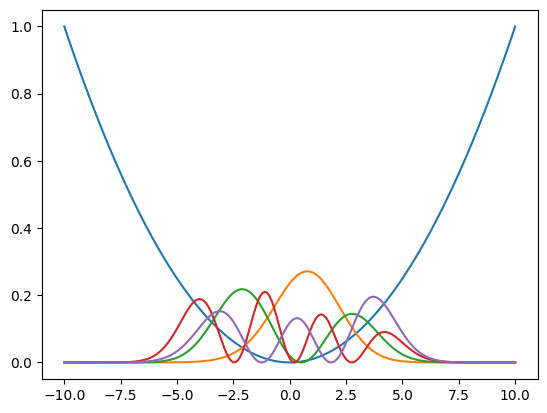

In [13]:
plt.plot(x, pot(x)/np.max(pot(x)), label='Scaled potential')
plt.plot(x, np.real(mctdhf.calculate_particle_densities(bs[-1], Cs[-1], spf).T))
plt.show()

Real time evolution

In [ ]:
ht = (x[1]-x[0])*contract('ij, j, kj -> ik', spf.conj(), x, spf)

@jit
def h_t(t, ht=ht):
    return ht*jnp.sin(2*t)

In [ ]:
mctdhf_rt = get_MCTDHF(h, h_t, g, num_mctdhf_orbitals, 
                num_spatial_orbitals, num_alpha_electrons, 
                num_beta_electrons, num_states, imag_time=False)

dt = 1e-2
integrator = get_runge_kutta_4_solver(mctdhf_rt, dt)
num_steps = int(4*2*np.pi/(0.25*8*dt))

ts_rt, Es_rt, Cs_rt, bs_rt = mctdhf_rt.integrate(integrator, num_steps=num_steps, t_init = 0, 
                                                b_init = jnp.array(bs[-1]), C_init = jnp.array(Cs[-1]))

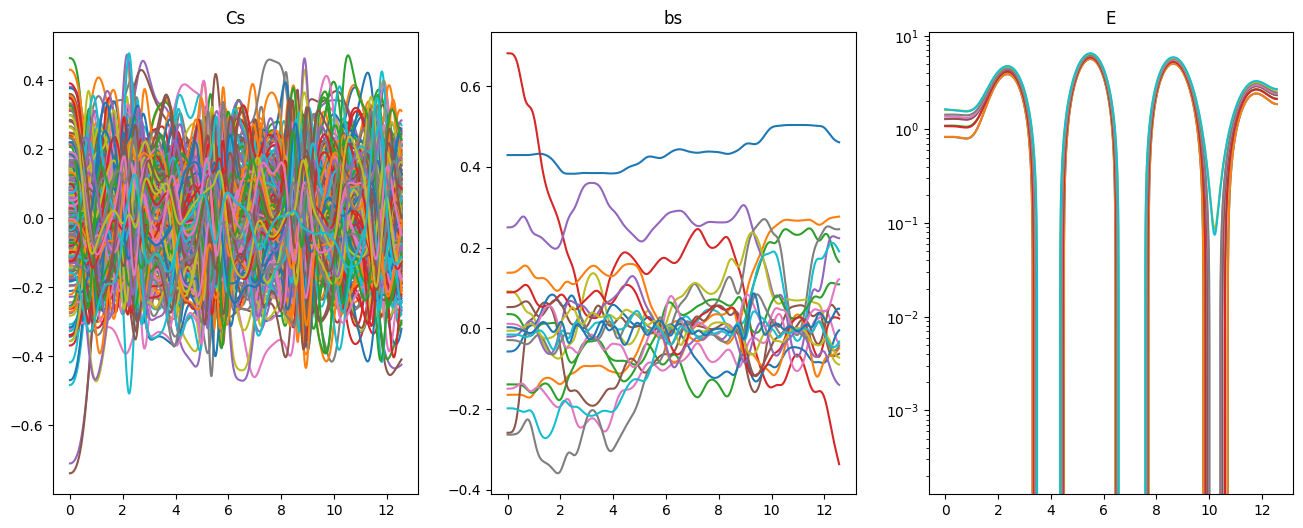

In [ ]:
mctdhf_rt.plot_Cbe(ts_rt, Cs_rt, bs_rt, Es_rt)

In [ ]:
overlap = [mctdhf_rt.calculate_overlap(bs[-1], Cs[-1], b, C) for b,C in zip(bs_rt, Cs_rt)]

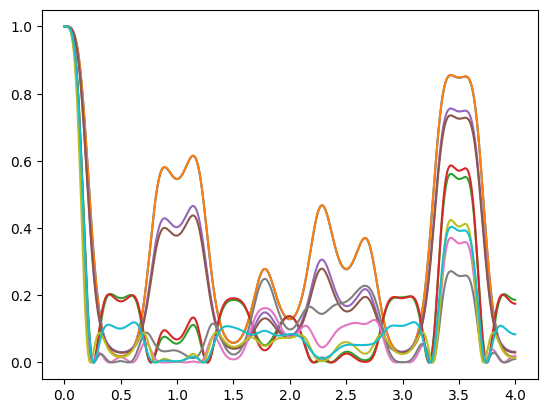

In [ ]:
plt.plot(np.array(ts_rt)*0.25*8/(2*np.pi), np.abs(overlap)**2)
plt.show()

## Compare with Zhangellini

In [ ]:
dt = 1e-2
num_steps = int(4*2*np.pi/(0.25*8*dt))

Ms = [1,2,3,4]

particle_densities = np.zeros((len(Ms), len(x)))
overlaps = np.zeros((len(Ms), num_steps+1))
gs_energies = np.zeros_like(Ms, np.double)

for i,M in enumerate(Ms):

    mctdhf = get_MCTDHF(h, lambda t: 0, g, M, 
                    num_spatial_orbitals, num_alpha_electrons, 
                    num_beta_electrons, imag_time=True)

    ts, Es, Cs, bs = mctdhf.integrate(num_steps = 5000, dt = 1e-2)
    particle_densities[i,:] = mctdhf.calculate_particle_density(bs[-1], Cs[-1], spf)
    gs_energies[i] = np.real(np.array(Es[-1]))

    mctdhf_rt = get_MCTDHF(h, h_t, g, M, 
                num_spatial_orbitals, num_alpha_electrons, 
                num_beta_electrons, imag_time=False)


    ts_rt, Es_rt, Cs_rt, bs_rt = mctdhf_rt.integrate(num_steps = num_steps, dt = dt, t_init = 0, 
                                                b_init = jnp.array(bs[-1]), C_init = jnp.array(Cs[-1]))

    overlaps[i,:] = np.abs(np.array([mctdhf.calculate_overlap(bs[-1], Cs[-1], b, C) for b,C in zip(bs_rt, Cs_rt)]))**2

Ground state energies
M=1: 1.1796600818634033
M=2: 0.8594634532928467
M=3: 0.8325561285018921
M=4: 0.8314194083213806


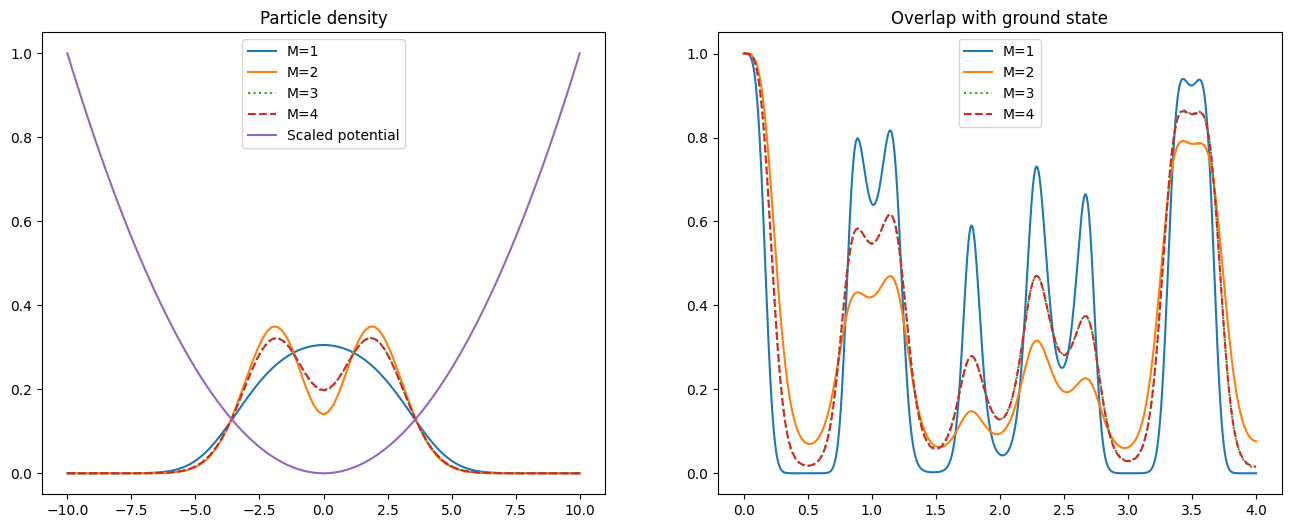

In [ ]:
t = np.linspace(0, 4, num_steps+1)
styles = ['-', '-', ':', '--']


fig, axs = plt.subplots(1, 2, figsize=(16,6))

print("Ground state energies")
for i,M in enumerate(Ms):
    print(f'M={M}: {gs_energies[i]}')
    axs[0].plot(x, particle_densities[i], label=f'M={M}', ls=styles[i])
    axs[1].plot(t, overlaps[i], label=f'M={M}', ls=styles[i])


axs[0].plot(x, pot(x)/np.max(pot(x)), label='Scaled potential')

axs[0].set_title('Particle density')
axs[1].set_title('Overlap with ground state')

for a in axs:
    a.legend()
plt.show()
